## SafeDerm — Gateway Threshold Tuning

Not part of the numbered 01-08 pipeline — this is a standalone validation notebook for `src/gateway.py`. It exists to pick a real `GATEWAY_THRESHOLD` instead of shipping the 0.5 default blind.

We run the gateway on two small sample sets — real skin images (from the HAM10000 train split) and random non-skin images — and look at how cleanly their `skin_score` distributions separate. Wherever they cross is roughly where the threshold should sit.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from pathlib import Path

from src.gateway import load_gateway_model, verify_image_is_skin
from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH
from src.dataset import SkinLesionDataset

### Load the gateway model

Same `build_*_model()` convention as `build_baseline_model()` — one load, reused for every image below.

In [2]:
gateway = load_gateway_model()
print(f"Gateway loaded on {gateway.device}")

e:\New folder (2)\safederm\.venv\Lib\site-packages\torch\cuda\__init__.py:188: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


Gateway loaded on cpu


### Sample real skin images

Pull ~20 images straight from the train split — these should all score high on `skin_score`.

In [3]:
N_SAMPLES = 20

train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=None)
skin_image_paths = [train_dataset.get_image_path(i) for i in range(N_SAMPLES)]

print(f"Collected {len(skin_image_paths)} real skin images")

Collected 20 real skin images


### Non-skin images

Drop ~20 random non-skin images (dogs, objects, scenery, unrelated medical scans) into `notebooks/gateway_ood_samples/` before running this cell. Not part of any tracked dataset — just a manual OOD sanity-check folder.

In [4]:
OOD_SAMPLES_DIR = Path("gateway_ood_samples")
non_skin_image_paths = sorted(OOD_SAMPLES_DIR.glob("*.*"))

print(f"Collected {len(non_skin_image_paths)} non-skin images")

Collected 2 non-skin images


### Run the gateway on both groups

In [5]:
skin_scores = [verify_image_is_skin(str(p), gateway)[1] for p in skin_image_paths]
non_skin_scores = [verify_image_is_skin(str(p), gateway)[1] for p in non_skin_image_paths]

print(f"Skin scores     — min: {min(skin_scores):.3f}  max: {max(skin_scores):.3f}")
print(f"Non-skin scores — min: {min(non_skin_scores):.3f}  max: {max(non_skin_scores):.3f}")

: 

### Score distribution

If the two histograms are cleanly separated, any threshold in the gap works. If they overlap, that overlap zone is where the gateway will make mistakes — worth inspecting those specific images.

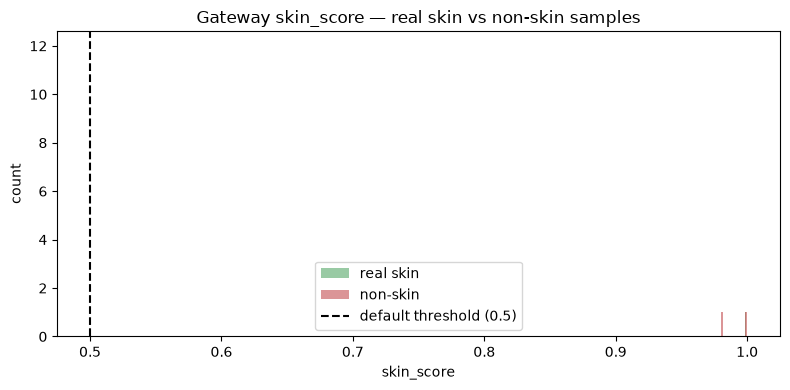

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(skin_scores, bins=15, alpha=0.6, label="real skin", color="#55A868")
ax.hist(non_skin_scores, bins=15, alpha=0.6, label="non-skin", color="#C44E52")
ax.axvline(0.5, color="black", linestyle="--", label="default threshold (0.5)")
ax.set_xlabel("skin_score")
ax.set_ylabel("count")
ax.set_title("Gateway skin_score — real skin vs non-skin samples")
ax.legend()
plt.tight_layout()
plt.show()

### Decide the threshold

Pick a value between the two distributions above (favor rejecting borderline images over letting them through — a retake prompt is cheap, a wrong clinical prediction on a bad input is not). Update `GATEWAY_THRESHOLD` in `src/config.py` to match, so the API and this notebook never drift out of sync.

In [ ]:
# CHOSEN_THRESHOLD = 0.xx  # fill in after reviewing the histogram above